# Sanity Check

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Load graph nodes
with open("../processed data/city_graph_nodes.json", "r") as f:
    city_nodes = json.load(f)

# Load graph edges
with open("../processed data/city_graph_edges.json", "r") as f:
    city_edges = json.load(f)

# Load device locations
device = pd.read_csv("../processed data/device_locations.csv")

### Check for Distinct City Nodes

In [3]:
num_nodes = len(city_nodes)
print("Number of distinct city nodes:", num_nodes)

Number of distinct city nodes: 900


### Number of City Edges

In [4]:
num_edges = len(city_edges)
print("Number of city edges:", num_edges)

Number of city edges: 1740


### Device Location on Graph

In [5]:
df_nodes = pd.DataFrame(city_nodes)

device_locations = set(device["location_id"].astype(str))
city_node_ids = set(df_nodes["id"].astype(str))

missing_nodes = device_locations - city_node_ids

print("Device locations not present in city graph:", len(missing_nodes))

Device locations not present in city graph: 0


### Users Distribution

Number of distinct users: 179
Rows per user:
user_id
0    142350
1    104246
2    213994
3    391666
4    374229
5    100025
6     24042
7     56704
8     77832
9     84416
Name: count, dtype: int64


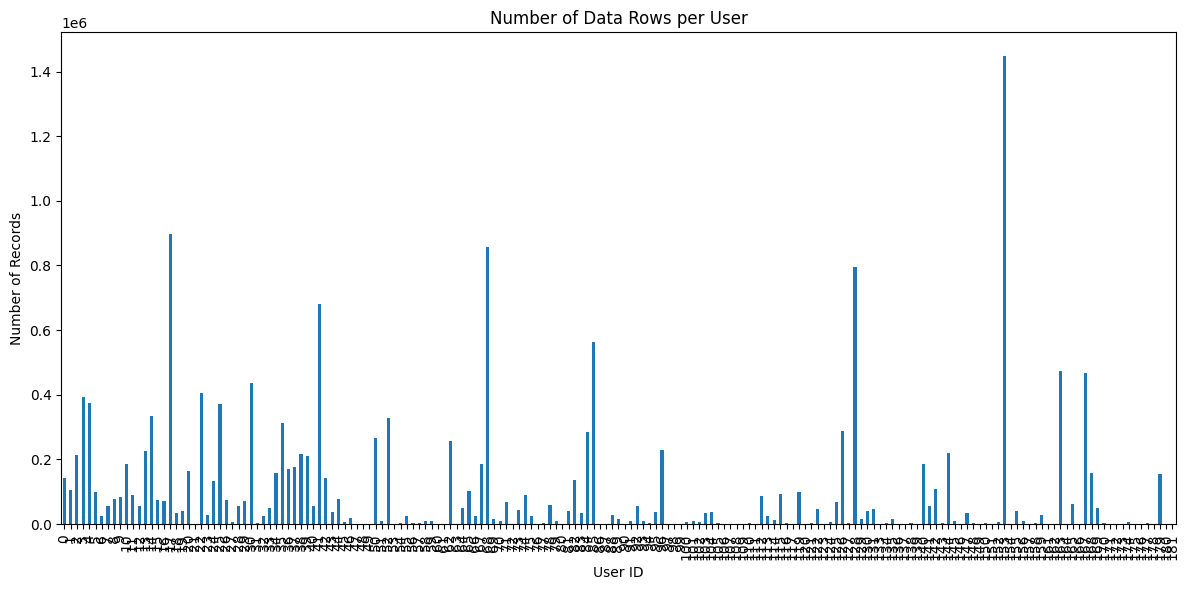

In [7]:
user_counts = device["user_id"].value_counts().sort_index()

print("Number of distinct users:", device["user_id"].nunique())
print("Rows per user:")
print(user_counts.head(10))

plt.figure(figsize=(12,6))
user_counts.plot(kind="bar")
plt.xlabel("User ID")
plt.ylabel("Number of Records")
plt.title("Number of Data Rows per User")
plt.tight_layout()
plt.show()

### Heatmap Distributions across grid

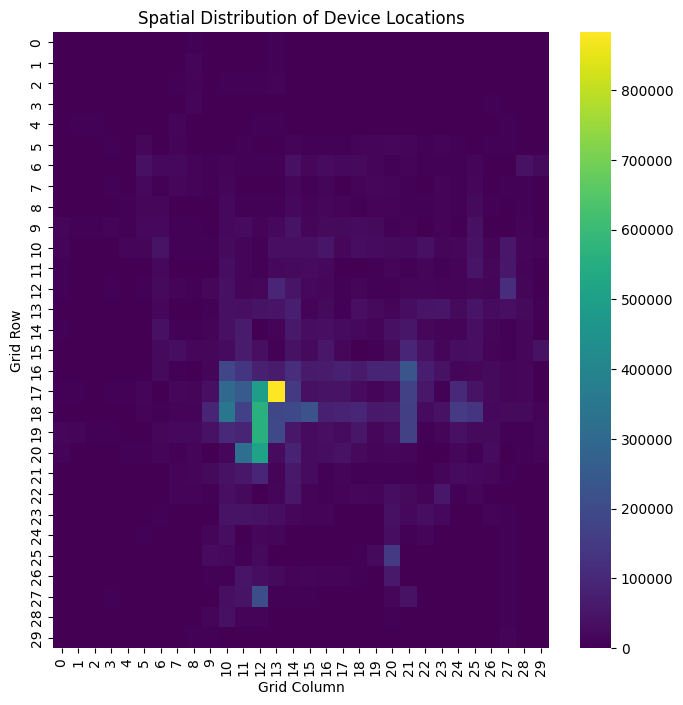

In [8]:
GRID_SIZE = 30

# Count visits per location
location_counts = device["location_id"].value_counts()

# Initialize empty grid
heatmap_grid = np.zeros((GRID_SIZE, GRID_SIZE))

for loc_id, count in location_counts.items():
    loc_id = int(loc_id)
    row = loc_id // GRID_SIZE
    col = loc_id % GRID_SIZE
    heatmap_grid[row, col] = count

plt.figure(figsize=(8,8))
sns.heatmap(heatmap_grid, cmap="viridis")
plt.title("Spatial Distribution of Device Locations")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.show()

## Statistical Analysis

### User Count Statistics

In [9]:
user_counts = device["user_id"].value_counts()

print("Average rows per user:", round(user_counts.mean(), 2))
print("Median rows per user:", user_counts.median())
print("Min rows per user:", user_counts.min())
print("Max rows per user:", user_counts.max())
print("Std deviation:", round(user_counts.std(), 2))

Average rows per user: 94422.14
Median rows per user: 24042.0
Min rows per user: 15
Max rows per user: 1448855
Std deviation: 185683.89


### Skewed Data Distribution Shape

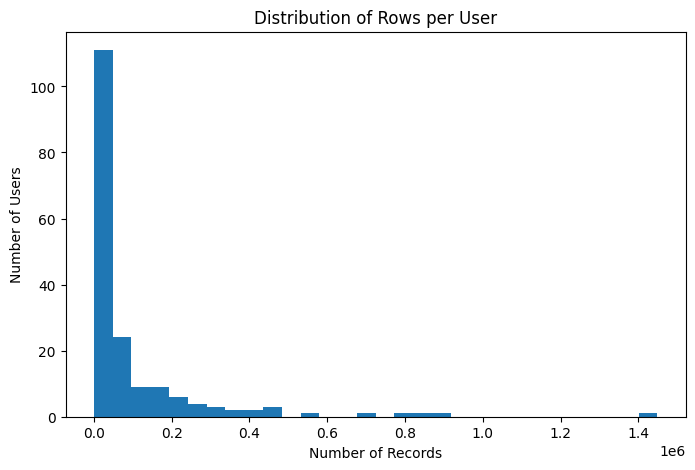

In [10]:
plt.figure(figsize=(8,5))
plt.hist(user_counts, bins=30)
plt.title("Distribution of Rows per User")
plt.xlabel("Number of Records")
plt.ylabel("Number of Users")
plt.show()

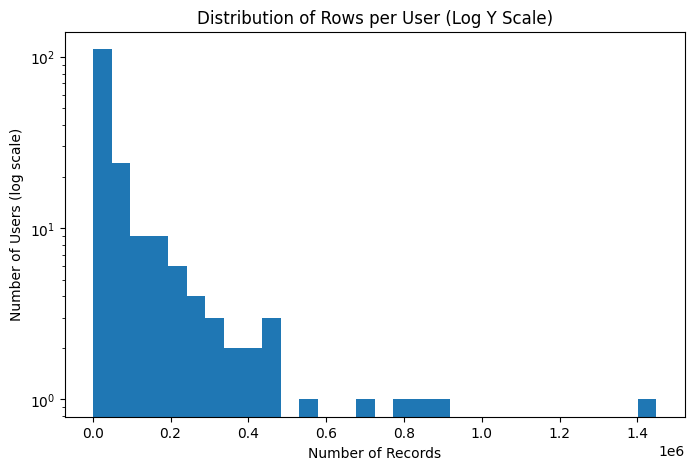

In [11]:
plt.figure(figsize=(8,5))
plt.hist(user_counts, bins=30)
plt.yscale("log")
plt.title("Distribution of Rows per User (Log Y Scale)")
plt.xlabel("Number of Records")
plt.ylabel("Number of Users (log scale)")
plt.show()

### Top 10 Heavy Users

In [12]:
print(user_counts.sort_values(ascending=False).head(10))

user_id
153    1448855
17      897805
68      856742
128     795827
41      681643
85      563536
163     473329
167     468747
30      437094
22      406111
Name: count, dtype: int64


### Normalized Heatmap

In [13]:
total_visits = heatmap_grid.sum()
normalized_grid = heatmap_grid / total_visits

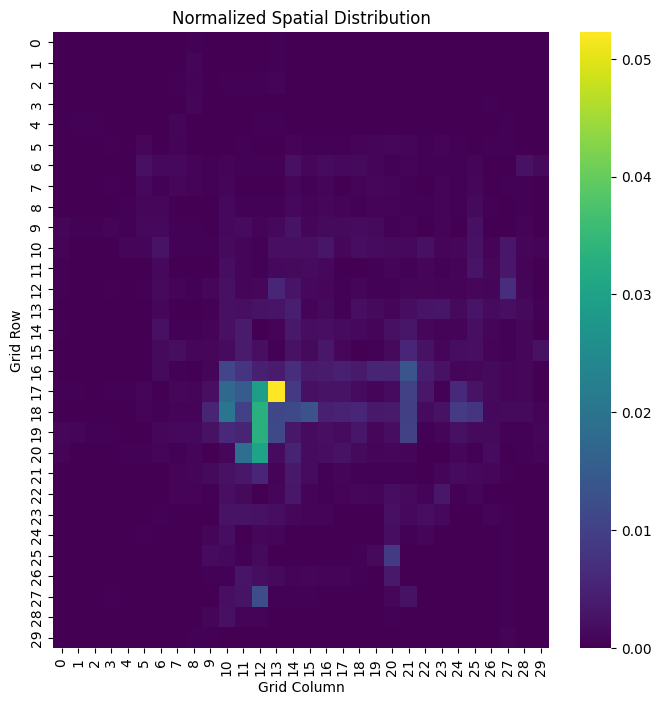

In [14]:
plt.figure(figsize=(8,8))
sns.heatmap(normalized_grid, cmap="viridis")
plt.title("Normalized Spatial Distribution")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.show()

### Spatial Uniformity Check

In [15]:
flat_counts = heatmap_grid.flatten()

print("Average visits per node:", round(flat_counts.mean(), 2))
print("Median visits per node:", round(np.median(flat_counts), 2))
print("Std deviation:", round(flat_counts.std(), 2))
print("Zero-visit nodes:", np.sum(flat_counts == 0))

Average visits per node: 18779.51
Median visits per node: 4363.0
Std deviation: 56271.42
Zero-visit nodes: 17


## Conclusion

### User Distribution

- Extreme Skew -> mean>>median
- Mean (94k) >> Median (24k)
- classic long-tail distribution, power-law shaped
- proves real data
- In human mobility datasets, that is expected:
    - A few users recorded for years.
    - Many users recorded briefly.

### Histogram Distribution

- On log scale heavy tailed distribution is seen
- Log Distribution looks roughly exponential
- Matches with typical human-generated activity

### Spatial Distribution

- Extreme Skew -> mean>>median
- Mean(18k) >> Mean(4k)
- Most grids have relatively low traffic
- Few Cells very high traffic
- Again corresponds with realistic human patterns
- Urban mobility clusters around:
    - Dense city center
    - Transport hubs
    - Major roads

### Spatial Coverage

- 17 Zero Visited Nodes
- About ~1.9%
- City Graph Grid is almost proper fit
- Spatial Coverage is good

## Summary

- Long-tail user activity
- Long-tail spatial concentration
- Small number of inactive nodes
- Strong central density

Symmetric to real mobility data

## Final Spatial Inequality Checks - Gini Coffecient

In [16]:
def gini(x):
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n+1)
    return (np.sum((2*index - n - 1) * x)) / (n * np.sum(x))

print("Spatial Gini:", round(gini(flat_counts), 3))

Spatial Gini: 0.78


### Algorithmic Accuracy and Effects

- Rare nodes → high re-identification risk
- Heavy users → dominate k-anonymity grouping
- Dense central nodes → higher anonymity
- Sparse edge nodes → lower anonymity

Thus, dataset is ideal for graph-based privacy experiments.

In [17]:
print("Total rows:", len(device))
print("Total heatmap sum:", heatmap_grid.sum())

Total rows: 16901563
Total heatmap sum: 16901563.0


- Perfectly Matches, so no grid accumulation bug

In [18]:
expected_ids = set(str(i) for i in range(900))
actual_ids = set(df_nodes["id"].astype(str))
print("Missing node IDs:", len(expected_ids - actual_ids))

Missing node IDs: 0


- No missing nodes, so proper